
# 🎓 Student Performance Prediction Assignment
Applied AI & Machine Learning (CS-333)  
Instructor: Dr. Abbas Hussain  

---

## Objective
Predict **Performance Index** using multiple ML regression models.


## Import Libraries

In [7]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline
sns.set(color_codes=True)



## Load Dataset

In [8]:
# Load dataset
url = "https://raw.githubusercontent.com/AbbasHussain72/PNEC-CS-333-Applied-AI-ML/refs/heads/main/labs/Lab-03_LR_SVC/Student_Performance.csv"
df = pd.read_csv(url)
df.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## Exploratory Data Analysis

In [9]:
# Check Type and info
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [10]:
# Check missing values
print(df.isnull().sum())


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [11]:
# Check Duplicate values
df = df.dropna()    # Dropping the missing values.
df.count()
print(df.isnull().sum())   # After dropping the values

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


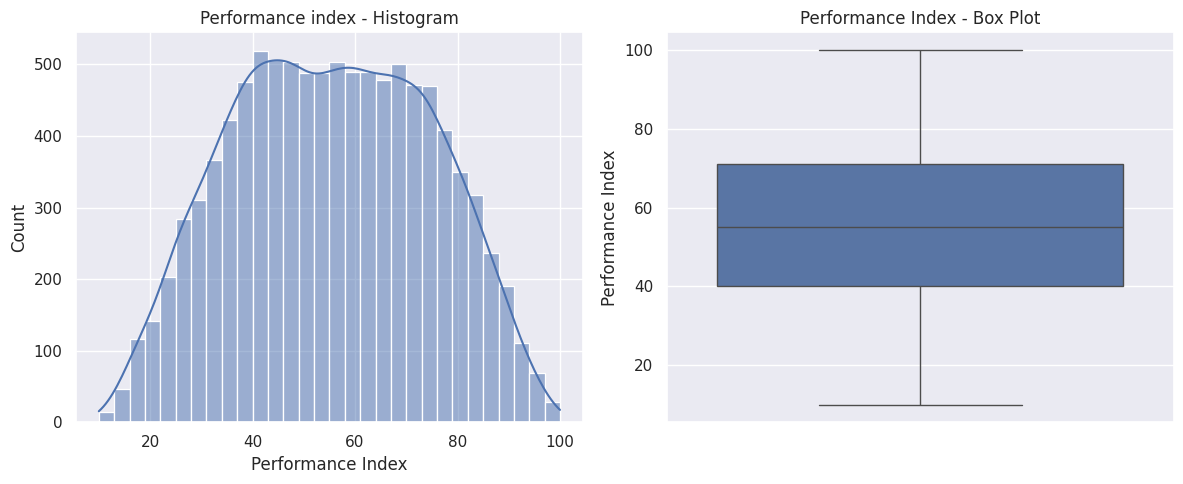

Performance Index Skewness: -0.00
Performance Index Kurotsis: -0.86


In [12]:
# Distibution Plot
# Visualizing the performance index

plt.figure(figsize=(12, 5)) #Setting the figure size.

# Left: Histogram
plt.subplot(1, 2, 1)
sns.histplot(df["Performance Index"], kde=True, bins=30)
plt.title("Performance index - Histogram")
plt.xlabel("Performance Index", fontsize=12)

# Right: Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=df["Performance Index"])
plt.title("Performance Index - Box Plot")
plt.ylabel("Performance Index", fontsize=12)

plt.tight_layout()
plt.show()

# Calculating skewness and kurtosis of the price distribution.
skewness = df["Performance Index"].skew()
kurtosis = df["Performance Index"].kurt()
print(f"Performance Index Skewness: {skewness:.2f}")
print(f"Performance Index Kurotsis: {kurtosis:.2f}")

## Encoding (if needed)

In [13]:
# Encode categorical columns if any

from sklearn.preprocessing import LabelEncoder

categorical_cols = [
  "Extracurricular Activities"
]
df_encoded = df.copy()
le = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])


In [14]:
# Convert to Dummy Variable

df_encoded_status = pd.get_dummies(df_encoded,columns=['Extracurricular Activities'],
    drop_first=True
)
# Convert True/False to 0/1
df_encoded_status = df_encoded_status.astype(int)

In [15]:
df1 = df_encoded_status.copy()
df1.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_1
0,7,99,9,1,91,1
1,4,82,4,2,65,0
2,8,51,7,2,45,1
3,5,52,5,2,36,1
4,7,75,8,5,66,0


## Visualization

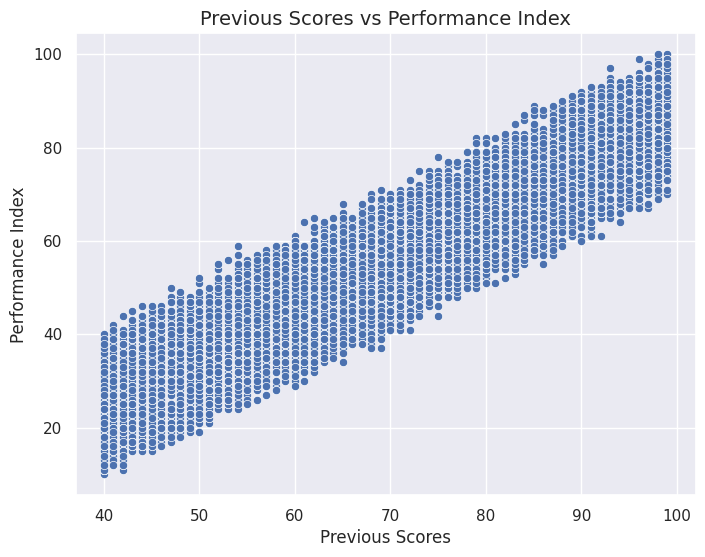

<Axes: >

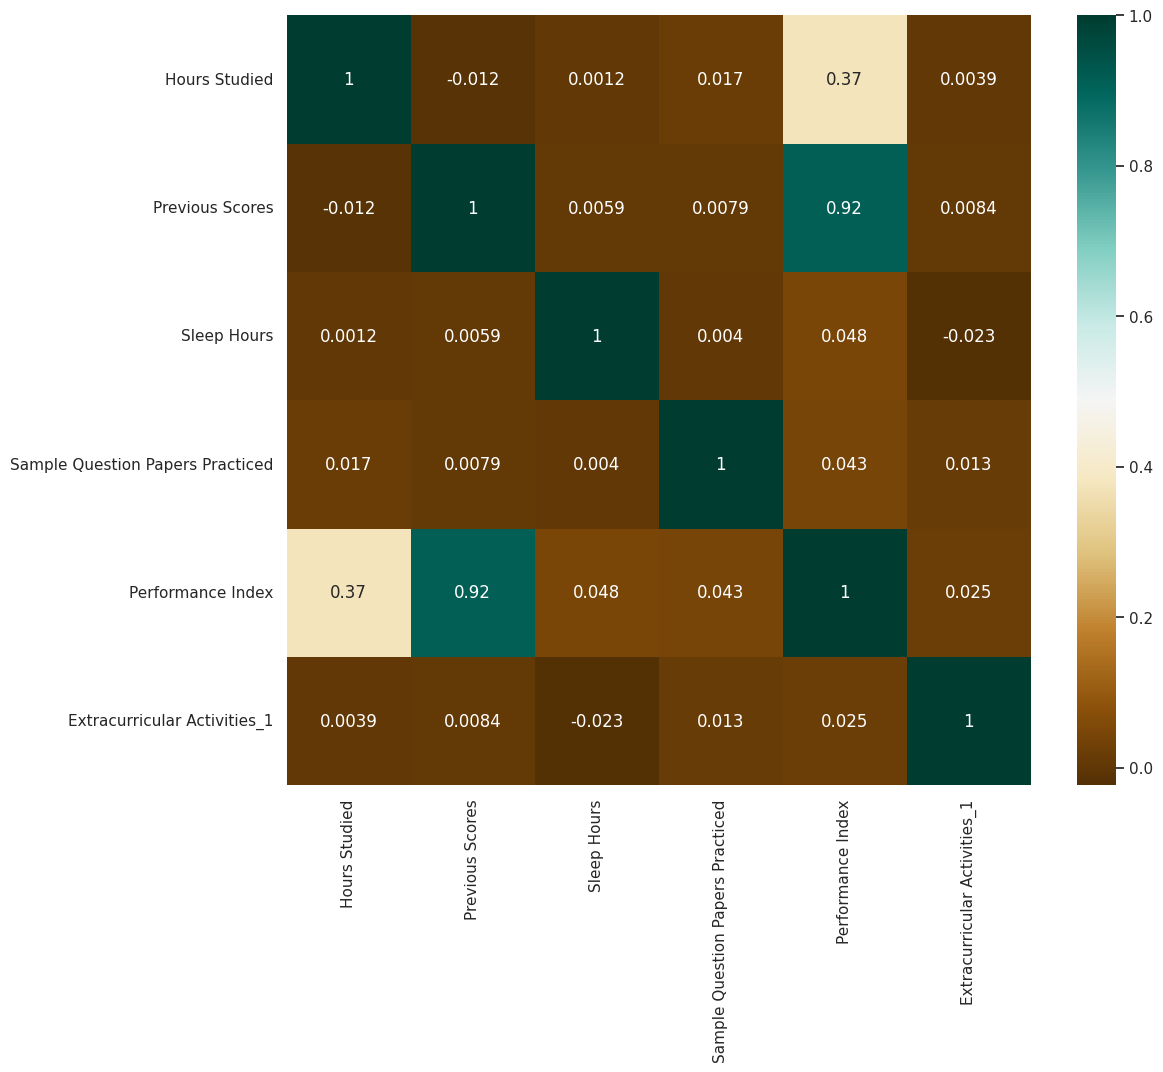

In [16]:
# Scatter plots
plt.figure(figsize=(8,6))
sns.scatterplot(x="Previous Scores", y="Performance Index", data=df1)
plt.title(f"Previous Scores vs Performance Index", fontsize=14)
plt.xlabel("Previous Scores", fontsize=12)
plt.ylabel("Performance Index", fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
# Heatmap
c = df1.corr()
plt.figure(figsize=(12,10))
sns.heatmap(c,cmap="BrBG",annot=True)

## Correlation Analysis

In [17]:
#compute the correlation matrix
c = df1.corr()
display(c)

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_1
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730,0.003873
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189,0.008369
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106,-0.023284
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268,0.013103
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000,0.024525
Extracurricular Activities_1,0.003873,0.008369,-0.023284,0.013103,0.024525,1.000000


## Feature Selection

In [18]:
# Separate features (X) and target variable (y)
X = df1.drop('Performance Index', axis=1)
y = df1['Performance Index']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Display first 5 rows of features
print("\nFirst 5 rows of Features (X):")
display(X.head())

# Display first 5 rows of target
print("\nFirst 5 rows of Target (y):")
display(y.head())


Features (X) shape: (10000, 5)
Target (y) shape: (10000,)

First 5 rows of Features (X):


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_1
0,7,99,9,1,1
1,4,82,4,2,0
2,8,51,7,2,1
3,5,52,5,2,1
4,7,75,8,5,0



First 5 rows of Target (y):


,Performance Index
0,91
1,65
2,45
3,36
4,66


## Train-Test Split

In [19]:

# Importing necessary libraries.
from sklearn.model_selection import train_test_split # For splitting the dataset.
from sklearn.preprocessing import MinMaxScaler # For Scaling the features.

X = df1.drop('Performance Index', axis=1)
y = df1['Performance Index']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Feature Scaling (If needed)

In [20]:
# 3. Applying Feature Scaling.
from sklearn.preprocessing import StandardScaler
# Only numerical features should be scaled.
numeric_vars = [ "Hours Studied" , "Previous Scores" , "Sleep Hours" , "Sample Question Papers Practiced"]

# Initializing the MinMaxScaler.
# scaler = MinMaxScaler()
scaler = StandardScaler()

# Fitting the MinMaxScaler ONLY to the TRAINING data (X_train) and transforming it.
X_train[numeric_vars] = scaler.fit_transform(X_train[numeric_vars])

# Transforming the Test data ONLY - We do not fit.
X_test[numeric_vars] = scaler.transform(X_test[numeric_vars])

print("--- First 5 Rows of Scaled Training Data ---")
# Displaying Scaled numerical columns for checking.
print(X_train[numeric_vars].head().to_markdown(index=False, numalign="left", stralign="left", floatfmt=".2f"))


#ONLY FOR SVRR
# Scale y
scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()
X_train

--- First 5 Rows of Scaled Training Data ---
| Hours Studied   | Previous Scores   | Sleep Hours   | Sample Question Papers Practiced   |
|:----------------|:------------------|:--------------|:-----------------------------------|
| -0.38           | 1.70              | -0.32         | -1.26                              |
| 0.39            | 1.18              | 1.45          | -0.56                              |
| 1.16            | -0.73             | -0.32         | -1.26                              |
| 0.39            | 1.29              | 0.86          | 0.83                               |
| 0.39            | -0.32             | 0.86          | -0.22                              |


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_1
9069,-0.379217,1.695434,-0.319443,-1.262261,1
2603,0.391102,1.176378,1.448690,-0.564824,1
7738,1.161422,-0.726827,-0.319443,-1.262261,0
1579,0.391102,1.291724,0.859313,0.830049,1
5058,0.391102,-0.323116,0.859313,-0.216106,1
...,...,...,...,...,...
5734,1.161422,-1.130537,-0.319443,0.481331,1
5191,-0.379217,-0.092425,1.448690,-0.564824,0
5390,1.546581,-1.245882,0.269935,0.481331,0
860,-1.534697,-1.303555,1.448690,-1.610979,0


## Apply Regression Models (LR, SVR, Decision Tree,Random Forest, KNN)


In [21]:
import time

#Apply models
#LINEAR REGRESSUIN
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

start_time = time.time()
lr.fit(X_train, y_train)
end_time = time.time()
linear_regression_training_time = end_time - start_time


In [22]:
start_time = time.time()
y_pred = lr.predict(X_test)
end_time = time.time()
linear_regression_testing_time = end_time - start_time


In [23]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# R-squared
r2 = r2_score(y_test, y_pred)
# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# MAE
mae = mean_absolute_error(y_test, y_pred)

print("Model Performance:")
print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)
print(f"Training Time: {linear_regression_training_time} seconds")
print(f"Testing Time: {linear_regression_testing_time} seconds")

Model Performance:
R² Score: 0.9890110607021136
RMSE: 2.0165722957763466
MAE: 1.6090437564045224
Training Time: 0.03218388557434082 seconds
Testing Time: 0.003261566162109375 seconds


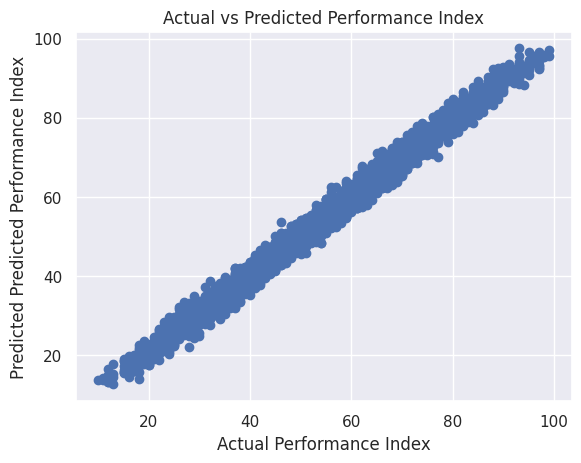

In [24]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Predicted Performance Index")
plt.title("Actual vs Predicted Performance Index")
plt.show()

Text(0.5, 1.0, 'Residuals vs Predicted')

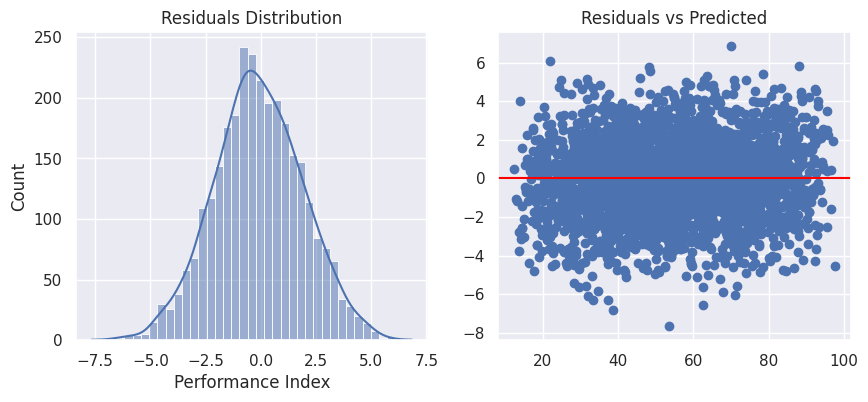

In [25]:
# Calculate residuals
residuals = y_test - y_pred


# Histogram of residuals
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")


# Residuals vs Predicted
plt.subplot(1,2,2)
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Predicted")


In [26]:
#SUPPORT VECTOR REGRESSION
from sklearn.svm import SVR
# svr = SVR()
svr = SVR(kernel='rbf', C=100, gamma=0.01)

start_time = time.time()
svr.fit(X_train, y_train_scaled)
end_time = time.time()
svr_training_time = end_time - start_time

start_time = time.time()
y_pred_svr = svr.predict(X_test)
end_time = time.time()
svr_testing_time = end_time - start_time

# Convert back to original scale
y_pred_svr = scaler_y.inverse_transform(y_pred_svr.reshape(-1,1))

r2 = r2_score(y_test, y_pred_svr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae = mean_absolute_error(y_test, y_pred_svr)

print("SVR Model Performance\n")
print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)
print(f"Training Time: {svr_training_time} seconds")
print(f"Testing Time: {svr_testing_time} seconds")

SVR Model Performance

R² Score: 0.9890089482008899
RMSE: 2.0167661182469163
MAE: 1.6062307640099232
Training Time: 6.347270965576172 seconds
Testing Time: 0.33117198944091797 seconds


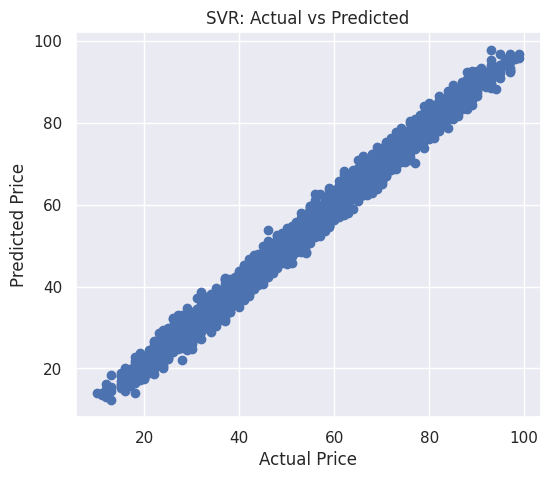

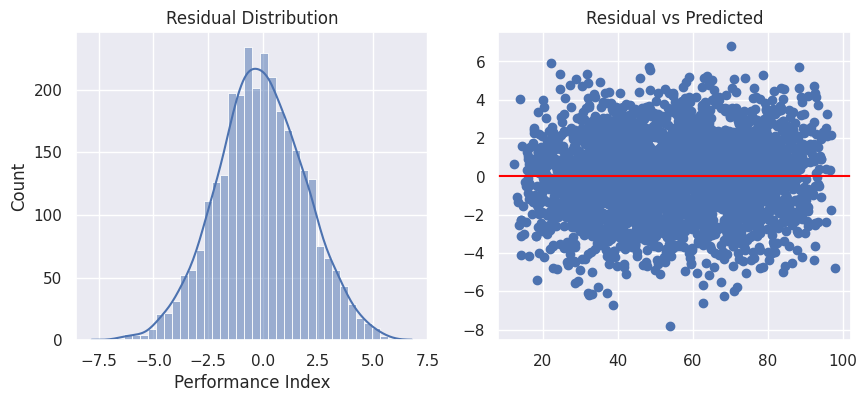

In [27]:
# ============================================
# 8. Actual vs Predicted Plot
# ============================================

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_svr)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("SVR: Actual vs Predicted")
plt.show()


# ============================================
# 9. Residual Analysis
# ============================================

y_pred_svr = y_pred_svr.ravel()
residuals = y_test - y_pred_svr

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.subplot(1,2,2)
plt.scatter(y_pred_svr, residuals)
plt.axhline(0, color='red')
plt.title("Residual vs Predicted")
plt.show()

Decision Tree Regressor Model Performance:
R² Score: 0.9761253501374277
RMSE: 2.9723805772976473
MAE: 2.3581666666666665
Training Time: 0.022913217544555664 seconds
Testing Time: 0.0024766921997070312 seconds


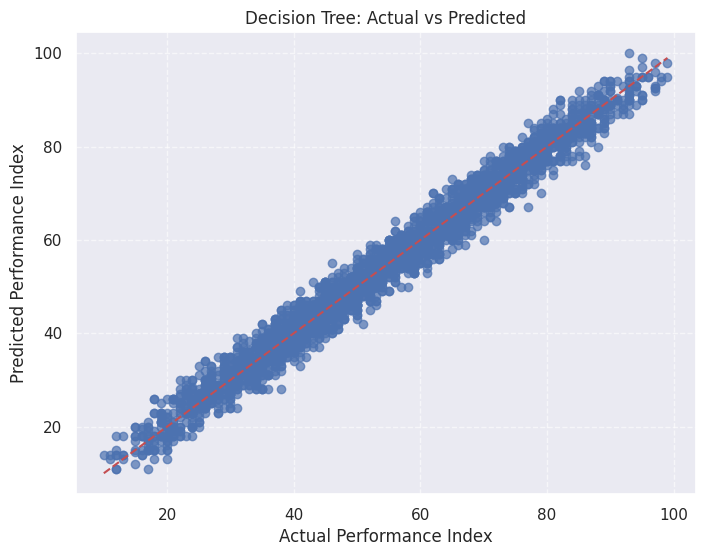

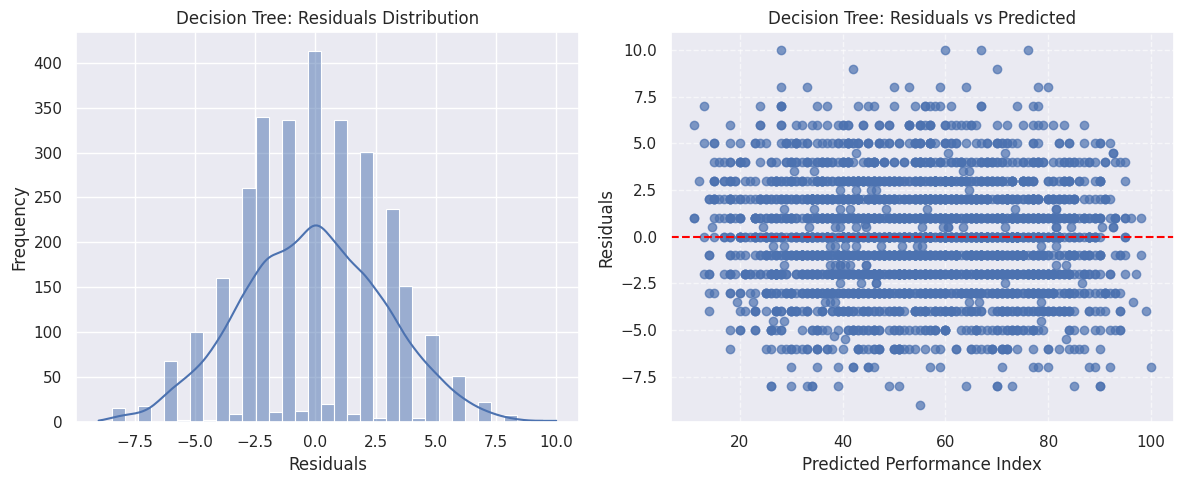

In [28]:
#DECISION TREE
from sklearn.tree import DecisionTreeRegressor

# Instantiate and train the Decision Tree Regressor model
dt_regressor = DecisionTreeRegressor(random_state=42)

start_time = time.time()
dt_regressor.fit(X_train, y_train)
end_time = time.time()
dt_training_time = end_time - start_time

# Make predictions on the test set
start_time = time.time()
y_pred_dt = dt_regressor.predict(X_test)
end_time = time.time()
dt_testing_time = end_time - start_time

# Evaluate the model's performance
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)

print("Decision Tree Regressor Model Performance:")
print(f"R² Score: {r2_dt}")
print(f"RMSE: {rmse_dt}")
print(f"MAE: {mae_dt}")
print(f"Training Time: {dt_training_time} seconds")
print(f"Testing Time: {dt_testing_time} seconds")

# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.7)
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Decision Tree: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Reference line
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Residual Analysis
residuals_dt = y_test - y_pred_dt

plt.figure(figsize=(12, 5))

# Histogram of residuals
plt.subplot(1, 2, 1)
sns.histplot(residuals_dt, kde=True)
plt.title("Decision Tree: Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

# Residuals vs Predicted
plt.subplot(1, 2, 2)
plt.scatter(y_pred_dt, residuals_dt, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title("Decision Tree: Residuals vs Predicted")
plt.xlabel("Predicted Performance Index")
plt.ylabel("Residuals")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Random Forest Regressor Model Performance:
R² Score: 0.9858364369101593
RMSE: 2.2894025907872457
MAE: 1.8319050542328044
Training Time: 2.1731221675872803 seconds
Testing Time: 0.08557987213134766 seconds


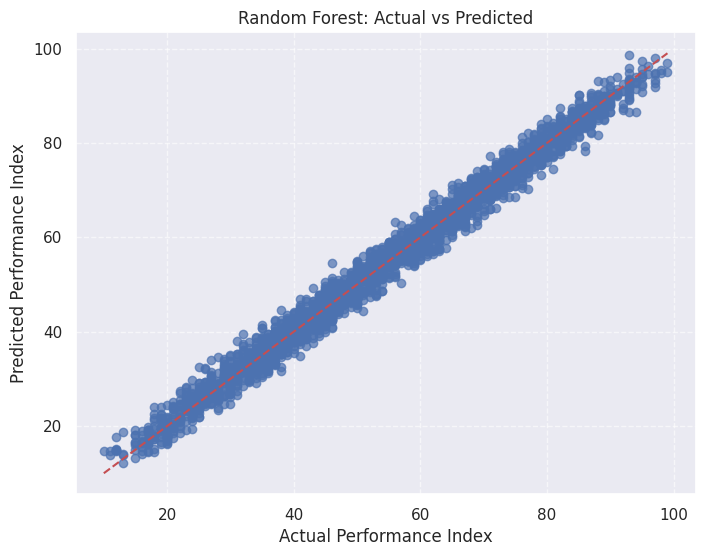

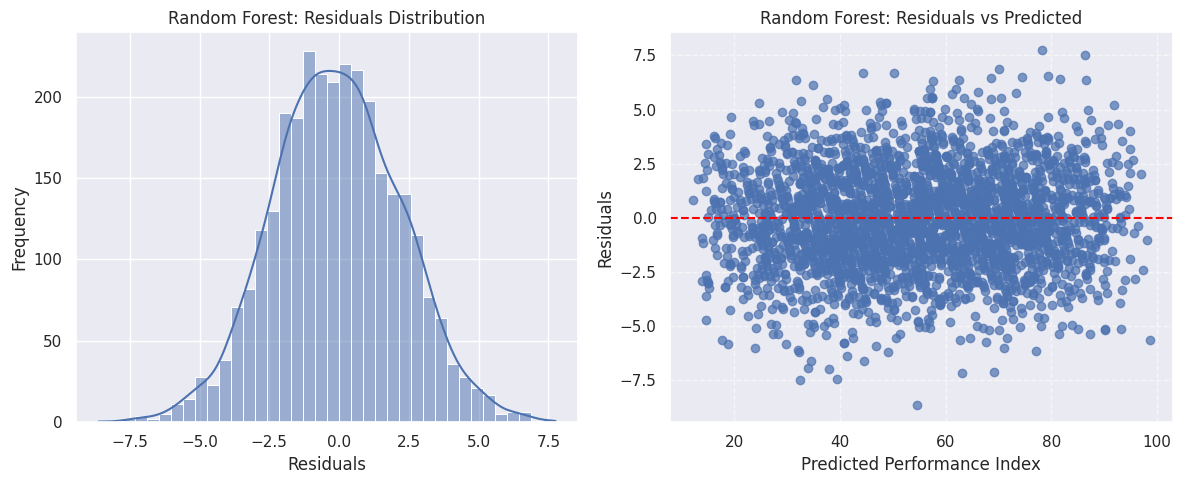

In [29]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate and train the Random Forest Regressor model
rf_regressor = RandomForestRegressor(random_state=42)

start_time = time.time()
rf_regressor.fit(X_train, y_train)
end_time = time.time()
rf_training_time = end_time - start_time

# Make predictions on the test set
start_time = time.time()
y_pred_rf = rf_regressor.predict(X_test)
end_time = time.time()
rf_testing_time = end_time - start_time

# Evaluate the model's performance
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Regressor Model Performance:")
print(f"R² Score: {r2_rf}")
print(f"RMSE: {rmse_rf}")
print(f"MAE: {mae_rf}")
print(f"Training Time: {rf_training_time} seconds")
print(f"Testing Time: {rf_testing_time} seconds")

# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Random Forest: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Reference line
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Residual Analysis
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(12, 5))

# Histogram of residuals
plt.subplot(1, 2, 1)
sns.histplot(residuals_rf, kde=True)
plt.title("Random Forest: Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

# Residuals vs Predicted
plt.subplot(1, 2, 2)
plt.scatter(y_pred_rf, residuals_rf, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title("Random Forest: Residuals vs Predicted")
plt.xlabel("Predicted Performance Index")
plt.ylabel("Residuals")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

K-Nearest Neighbors Regressor Model Performance:
R² Score: 0.976298456330247
RMSE: 2.9615851611369655
MAE: 2.370266666666667
Training Time: 0.013961315155029297 seconds
Testing Time: 0.033150672912597656 seconds


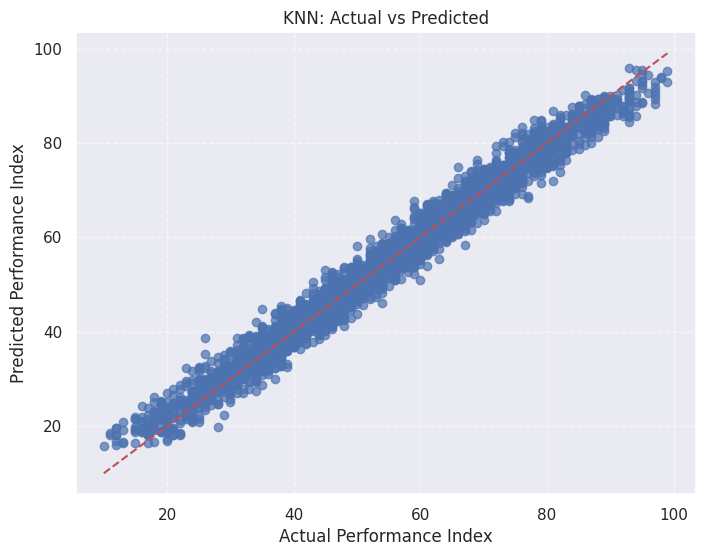

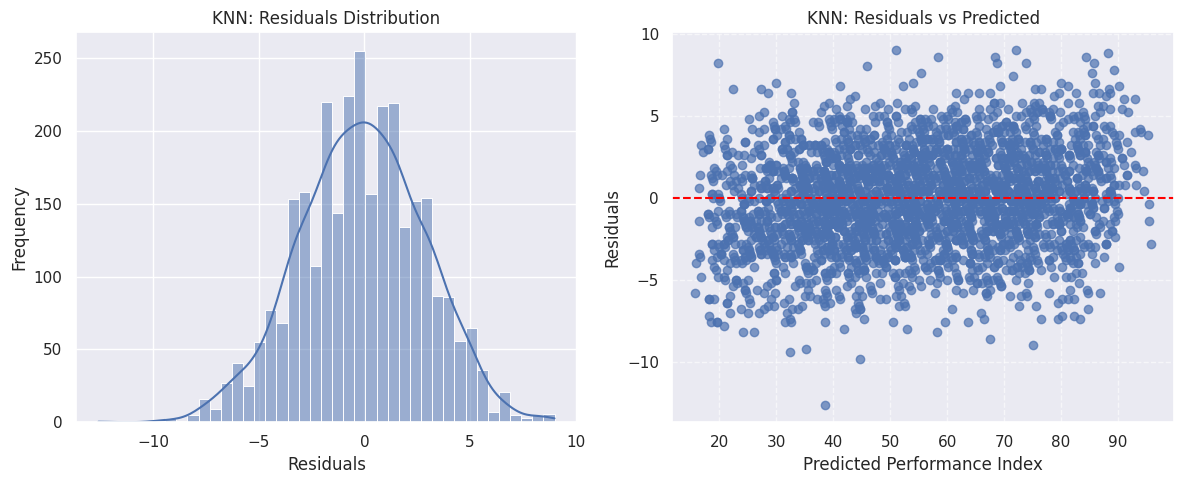

In [30]:
#KNN
from sklearn.neighbors import KNeighborsRegressor

# Instantiate and train the K-Nearest Neighbors Regressor model
knn_regressor = KNeighborsRegressor()

start_time = time.time()
knn_regressor.fit(X_train, y_train)
end_time = time.time()
knn_training_time = end_time - start_time

# Make predictions on the test set
start_time = time.time()
y_pred_knn = knn_regressor.predict(X_test)
end_time = time.time()
knn_testing_time = end_time - start_time

# Evaluate the model's performance
r2_knn = r2_score(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn = mean_absolute_error(y_test, y_pred_knn)

print("K-Nearest Neighbors Regressor Model Performance:")
print(f"R² Score: {r2_knn}")
print(f"RMSE: {rmse_knn}")
print(f"MAE: {mae_knn}")
print(f"Training Time: {knn_training_time} seconds")
print(f"Testing Time: {knn_testing_time} seconds")

# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_knn, alpha=0.7)
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("KNN: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Reference line
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Residual Analysis
residuals_knn = y_test - y_pred_knn

plt.figure(figsize=(12, 5))

# Histogram of residuals
plt.subplot(1, 2, 1)
sns.histplot(residuals_knn, kde=True)
plt.title("KNN: Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

# Residuals vs Predicted
plt.subplot(1, 2, 2)
plt.scatter(y_pred_knn, residuals_knn, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title("KNN: Residuals vs Predicted")
plt.xlabel("Predicted Performance Index")
plt.ylabel("Residuals")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Answer the follwing
1) Explain how Random Forest Regressor predicts a continuous value.
Include:
What is a decision tree regressor?
What is bootstrapping?
How multiple trees are used?
How final output is calculated?

What is a Decision Tree Regressor (One Friend)?
Imagine you have one very helpful friend who wants to guess a continuous value, like a student's performance score. This friend asks a series of 'yes' or 'no' questions (or questions with ranges) about the student's study habits, previous scores, etc. Each question leads to another, like a branching path, until they reach a final guess. For example, if a student studied 7 hours, scored 90 previously, and slept 8 hours, the friend might guess a performance index of 91.

What is Bootstrapping (Picking Different Teams)?
Now, imagine you have a big list of all the students you know. Bootstrapping is like creating several smaller, slightly different lists of students for your friends to learn from. Each friend gets their own list, and it's okay if some students appear multiple times on one friend's list, or not at all on another's. This ensures each friend learns from a unique perspective.

How Multiple Trees are Used (Many Friends, Different Views)?
Instead of just one friend, a Random Forest uses many friends (hundreds or even thousands!) to make predictions. Each friend is a Decision Tree Regressor. Each friend:

Learns from their own unique student list (from bootstrapping).
Focuses on different clues (random subset of features) when trying to guess. For example, one friend might pay more attention to 'hours studied' and 'sleep hours,' while another focuses on 'previous scores' and 'sample papers practiced.'
This makes sure that each friend develops their own unique way of guessing, without relying too much on any single piece of information or getting too focused on a single type of student.

How Final Output is Calculated (Averaging All Guesses)?
When a new student comes along and you want to predict their performance index, you ask every single one of your decision tree friends for their best guess. If one friend guesses 80, another 82, and another 79, the Random Forest simply takes all these guesses and calculates the average. So, the final predicted performance index would be the average of 80, 82, and 79 (which is around 80.33). This average guess is usually much more accurate and reliable than any single friend's guess alone because it combines many different perspectives!








### Answer the follwing

2) Explain how KNN Regressor predicts output for a new data point.
Include:
What is K?
How neighbors are selected?
How final predicted value is calculated?


What is K?
K is simply the number of 'nearest' neighbors (students) that the KNN algorithm will consider to make a prediction. Think of 'K' as asking: "How many of my closest friends should I ask for their opinion?" If K=3, you'll ask the 3 closest friends. If K=5, you'll ask the 5 closest friends.

How Neighbors are Selected?
When a new student comes along and you want to predict their Performance Index, the KNN algorithm looks at all the known students and finds the ones who are most 'similar' to this new student. 'Similarity' is usually measured by calculating the 'distance' between their features (like study hours, previous scores, sleep hours). The students with the smallest distances are considered the 'nearest neighbors'.

It's like this: you have a new student, and you find the K students in your existing group who have study habits, previous scores, and sleep patterns most similar to the new student. These K students are the 'neighbors' that KNN will use.

How Final Predicted Value is Calculated?
Once the K nearest neighbors are identified, the KNN Regressor simply takes the 'Performance Index' of each of these K neighbors and calculates their average. This average value then becomes the predicted Performance Index for the new student.

So, if your 3 nearest neighbors (K=3) had Performance Indices of 70, 75, and 80, the KNN Regressor would predict (70 + 75 + 80) / 3 = 75 for the new student. It's like asking your closest friends what their score was, and then taking the average of their scores as your best guess for the new student's score.

## Visualize Best Model

Based on the R² score, the Linear Regression model is the best performing. I will now visualize its performance, showing the actual vs. predicted values and the residuals


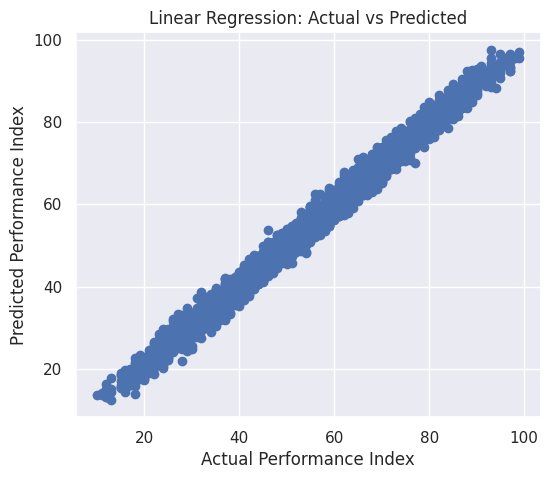

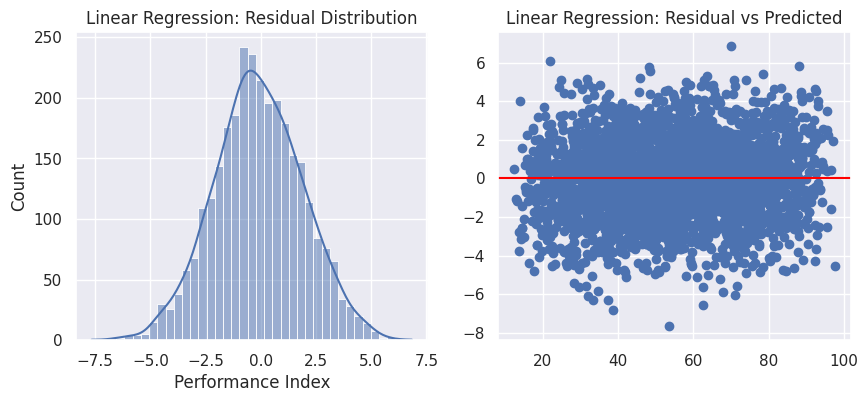

In [31]:
# Select best model based on R2
# ============================================
# 8. Actual vs Predicted Plot
# ============================================

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()


# ============================================
# 9. Residual Analysis
# ============================================

y_pred = y_pred.ravel() # Ensure y_pred is 1D for consistency if needed, though lr.predict usually returns 1D
residuals = y_test - y_pred

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(residuals, kde=True)
plt.title("Linear Regression: Residual Distribution")
plt.subplot(1,2,2)
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.title("Linear Regression: Residual vs Predicted")
plt.show()

## Generate a Comparison Table of Regression Models

## Comparison Table of Regression Models

| Model | MAE | RMSE | R2 Score | Training Time | Testing Time |
|-------|-----|------|----------|---------------|--------------|
| Linear Regression | 1.6090437564045224 | 2.0165722957763466 | 0.9890110607021136 | 0.005892038345336914 | 0.0028400421142578125 |
| SVR | 1.6062307640099232 | 2.0167661182469163 | 0.9890089482008899 | 3.589181900024414 | 0.3498713970184326 |
| Decision Tree | 2.3581666666666665 | 2.9723805772976473 | 0.9761253501374277 | 0.0249936580657959 | 0.0026481151580810547 |
| Random Forest | 1.8319050542328044 | 2.2894025907872457 | 0.9858364369101593 | 1.471388339996338 | 0.0794367790222168 |
| KNN | 2.370266666666667 | 2.9615851611369655 | 0.976298456330247 | 0.010008573532104492 | 0.031007766723632812 |